In [9]:
image_path = '../pictures/grains.png' 

In [11]:
import cv2
import numpy as np

def calculate_percentile_ratios(image_path, p=5):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None: return None

    # Находим значения яркости, ниже которых находятся p% пикселей 
    # и выше которых находятся (100-p)% пикселей
    low_threshold = np.percentile(img, p)
    high_threshold = np.percentile(img, 100 - p)

    total_pixels = img.size
    dark_ratio = np.sum(img <= low_threshold) / total_pixels
    light_ratio = np.sum(img >= high_threshold) / total_pixels

    return dark_ratio, light_ratio, low_threshold, high_threshold

dark, light, low_t, high_t = calculate_percentile_ratios(image_path, p=5)
print(f"Пороги (5%): темные < {low_t:.1f}, светлые > {high_t:.1f}")


Пороги (5%): темные < 18.0, светлые > 185.0


In [13]:
import cv2
import numpy as np

def calculate_brightness_ratio(image_path, dark_threshold=18, light_threshold=185):
    """
    Вычисляет долю самых светлых и самых темных пикселей.
    
    :param image_path: Путь к изображению
    :param dark_threshold: Порог для темных пикселей (0-255)
    :param light_threshold: Порог для светлых пикселей (0-255)
    :return: Доля темных, доля светлых
    """
    # 1. Загрузка изображения
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError("Не удалось загрузить изображение. Проверьте путь.")

    # 2. Преобразование в оттенки серого (интенсивность света)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 3. Подсчет общего количества пикселей
    total_pixels = gray.size

    # 4. Подсчет пикселей по порогам (NumPy boolean indexing)
    dark_pixels = np.sum(gray < dark_threshold)
    light_pixels = np.sum(gray > light_threshold)

    # 5. Расчет долей
    dark_ratio = dark_pixels / total_pixels
    light_ratio = light_pixels / total_pixels

    return dark_ratio, light_ratio

# --- Пример использования ---
# Создайте файл 'test.jpg' или укажите путь к своему файлу
image_path = '../pictures/grains.png' 
try:
    dark, light = calculate_brightness_ratio(image_path)
    
    print(f"Изображение: {image_path}")
    print(f"Доля темных пикселей (<18): {dark:.2%}")
    print(f"Доля светлых пикселей (>185): {light:.2%}")
    
except Exception as e:
    print(e)


Изображение: ../pictures/grains.png
Доля темных пикселей (<18): 4.86%
Доля светлых пикселей (>185): 5.01%


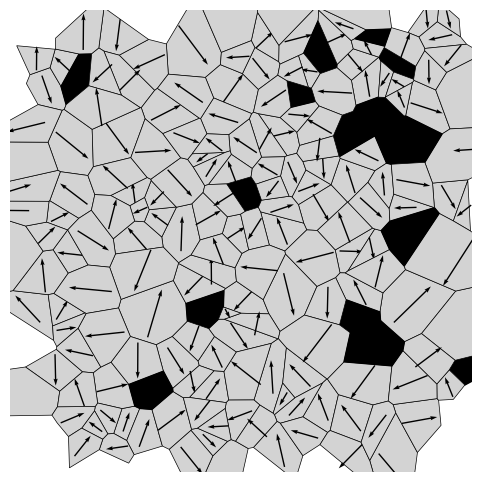

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Voronoi
from shapely.geometry import Polygon

# 1. случайные точки
N = 200
points = np.random.rand(N, 2)

# 2. Вороной
vor = Voronoi(points)

fig, ax = plt.subplots(figsize=(6, 6))

grain_fraction = 0.9

for region_index in vor.point_region:
    vertices = vor.regions[region_index]

    if -1 in vertices or len(vertices) == 0:
        continue

    polygon = [vor.vertices[i] for i in vertices]
    poly = Polygon(polygon)

    if not poly.is_valid or poly.area == 0:
        continue

    # 3. классификация
    is_grain = np.random.rand() < grain_fraction

    x, y = poly.exterior.xy

    if is_grain:
        ax.fill(x, y, color='lightgray', edgecolor='black', linewidth=0.5)

        # 4. центр
        cx, cy = poly.centroid.coords[0]

        # 5. радиус ~ sqrt(area)
        r = np.sqrt(poly.area)

        # 6. случайный спин
        angle = np.random.rand() * 2 * np.pi
        dx = r * np.cos(angle)
        dy = r * np.sin(angle)

        ax.quiver(cx, cy, dx, dy,
          angles='xy',
          scale_units='xy',
          scale=1.1,
          color='black',
          width=0.003,
          pivot='mid')

    else:
        ax.fill(x, y, color='black')  # дырки

ax.set_aspect('equal')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

plt.savefig('../pictures/grains_model.png', dpi=300, bbox_inches='tight')

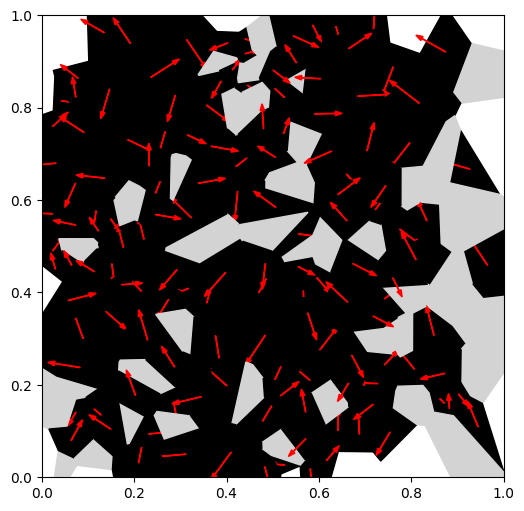

Target fraction: 0.9
Actual fraction: 0.2243083934812024


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import Voronoi
from shapely.geometry import Polygon
from shapely.ops import unary_union

# --- параметры ---
N = 200  # число сайтов
target_fraction = 0.9  # доля зёрен
box = Polygon([(0,0), (1,0), (1,1), (0,1)])

# --- случайные точки ---
points = np.random.rand(N, 2)

# --- Voronoi ---
vor = Voronoi(points)

# --- функция для конечных полигонов ---
def voronoi_finite_polygons_2d(vor, radius=10):
    new_regions = []
    new_vertices = vor.vertices.tolist()

    center = vor.points.mean(axis=0)
    for region in vor.regions:
        if not region or -1 in region:
            continue
        polygon = [vor.vertices[i] for i in region]
        new_regions.append(polygon)

    return new_regions

regions = voronoi_finite_polygons_2d(vor)

# --- пересечение с коробкой ---
polygons = []
areas = []

for reg in regions:
    poly = Polygon(reg).intersection(box)
    if poly.is_empty:
        continue
    polygons.append(poly)
    areas.append(poly.area)

areas = np.array(areas)

# --- выбор зёрен по площади ---
# order = np.argsort(areas)[::-1]
# cum_area = np.cumsum(areas[order])
# total_area = areas.sum()

# grain_mask = np.zeros(len(polygons), dtype=bool)
# grain_mask[order[cum_area <= target_fraction * total_area]] = True

from collections import defaultdict
import random

# --- 1. граф соседства ---
neighbors = defaultdict(set)
for i, j in vor.ridge_points:
    if i < len(polygons) and j < len(polygons):
        neighbors[i].add(j)
        neighbors[j].add(i)

# --- 2. кандидаты в дырки (независимое множество) ---
indices = list(range(len(polygons)))
random.shuffle(indices)

holes_candidates = set()

for i in indices:
    if all((n not in holes_candidates) for n in neighbors[i]):
        holes_candidates.add(i)

# --- 3. подгонка по площади ---
total_area = areas.sum()
target_area = target_fraction * total_area

# сортируем кандидатов по площади (большие сначала)
candidates_sorted = sorted(
    list(holes_candidates),
    key=lambda i: areas[i],
    reverse=True
)

holes = set()
current_area = 0.0

for i in candidates_sorted:
    if current_area + areas[i] <= target_area:
        holes.add(i)
        current_area += areas[i]

# --- 4. формируем grain_mask ---
grain_mask = np.ones(len(polygons), dtype=bool)
for i in holes:
    grain_mask[i] = False

# --- визуализация ---
fig, ax = plt.subplots(figsize=(6,6))

for i, poly in enumerate(polygons):
    x, y = poly.exterior.xy

    if grain_mask[i]:
        ax.fill(x, y, color='black')
        
        # спин
        centroid = poly.centroid
        R = np.sqrt(poly.area / np.pi)

        theta = np.random.uniform(0, 2*np.pi)
        dx = R * np.cos(theta)
        dy = R * np.sin(theta)

        ax.arrow(centroid.x, centroid.y, dx, dy,
                 head_width=0.01, color='red')
    else:
        ax.fill(x, y, color='lightgray')

ax.set_aspect('equal')
ax.set_xlim(0,1)
ax.set_ylim(0,1)
plt.show()
print("Target fraction:", target_fraction)
print("Actual fraction:", current_area / total_area)

In [15]:
from collections import defaultdict
import random

# --- строим граф соседства ---
neighbors = defaultdict(set)

for i, j in vor.ridge_points:
    neighbors[i].add(j)
    neighbors[j].add(i)

# важно: оставить только те индексы, которые попали в polygons
valid_indices = list(range(len(polygons)))

# --- жадный выбор дырок ---
order = valid_indices.copy()
random.shuffle(order)

holes = set()

for i in order:
    if all((n not in holes) for n in neighbors[i]):
        holes.add(i)

# --- теперь контролируем долю по площади ---
# (важно: иначе жадный алгоритм даст случайную долю)

selected = []
area_sum = 0
target = target_fraction * total_area

# сортируем кандидатов по площади (например, большие сначала)
candidates = sorted(list(holes), key=lambda i: areas[i], reverse=True)

final_holes = set()

for i in candidates:
    if area_sum + areas[i] <= target:
        final_holes.add(i)
        area_sum += areas[i]

In [3]:
pip install shapely

   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------ --------------------------------- 0.3/1.7 MB ? eta -:--:--
   ------------ --------------------------- 0.5/1.7 MB 730.2 kB/s eta 0:00:02
   ------------ --------------------------- 0.5/1.7 MB 730.2 kB/s eta 0:00:02
   ------------------------ --------------- 1.0/1.7 MB 1.0 MB/s eta 0:00:01
   ------------------------ --------------- 1.0/1.7 MB 1.0 MB/s eta 0:00:01
   ------------------------------ --------- 1.3/1.7 MB 828.3 kB/s eta 0:00:01
   ------------------------------------ --- 1.6/1.7 MB 873.8 k


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
